In [1]:
import logging
import os
import sys
import traceback
from tqdm import tqdm 

from hydra import initialize, compose
import numpy as np
import pandas as pd
from omegaconf import DictConfig
import scanpy as sc
import torch

import sys 
sys.path.insert(0, "../../../../../shared_utils")
from experiment_utils import get_forward_model

from torch.utils.data import TensorDataset, DataLoader

In [2]:
with initialize(config_path="../../../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=default"
                    ])

In [3]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

# Classify both training and validation anndata 

In [4]:
train_data = target_prediction_model.train_data.state_data
valid_data = target_prediction_model.validation_data.state_data

In [5]:
label_train = target_prediction_model.train_data.adata.obs.cell_type.to_numpy()
label_valid = target_prediction_model.validation_data.adata.obs.cell_type.to_numpy()

In [6]:
X_concat = torch.from_numpy(np.concatenate([train_data, valid_data], axis=0))
label_concat = np.concatenate([label_train, label_valid])

## Tensor dataset for data 

In [7]:
dataloader = DataLoader(
    torch.utils.data.TensorDataset(X_concat), 
    batch_size=4026,
    shuffle=False
)

In [8]:
ct_predictions = []

with torch.no_grad():
    for batch in tqdm(dataloader):
        X_batch = batch[0].to(target_prediction_model.device)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions.append(y_pred.cpu().detach().numpy())

100%|██████████| 25/25 [00:02<00:00,  9.52it/s]


In [9]:
ct_predictions = np.concatenate(ct_predictions)

In [10]:
from sklearn.preprocessing import LabelEncoder

# Prepare label encoder
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [11]:
ct_predictions_str = classes[ct_predictions]

In [12]:
pd.DataFrame(ct_predictions_str).value_counts()

0                   
MPP                     17200
GMP-Neutro              14433
GMP-Cycle               13749
pDCs/cDCs               13165
MEP                      8211
CD49c-Myeloid            6683
EosBasoMastPre           6489
MLP                      5780
EosBasoMastPre_2         4411
EryPro                   3160
CD14-Mono                1768
CyclingProgenitor*       1213
GMP-Neutro/CD16-Mono      991
HSCs                      764
Early_Pro-B               626
EarlyGMP                  491
Pro-B                     467
MgkPro                    218
DCs-CD14                  181
Name: count, dtype: int64

In [13]:
ct_predictions_str

array(['GMP-Neutro', 'pDCs/cDCs', 'GMP-Cycle', ..., 'GMP-Cycle', 'MEP',
       'MLP'], shape=(100000,), dtype='<U20')

In [14]:
label_concat

array(['GMP-Neutro', 'pDCs/cDCs', 'GMP-Cycle', ..., 'GMP-Cycle', 'MEP',
       'MLP'], shape=(100000,), dtype=object)

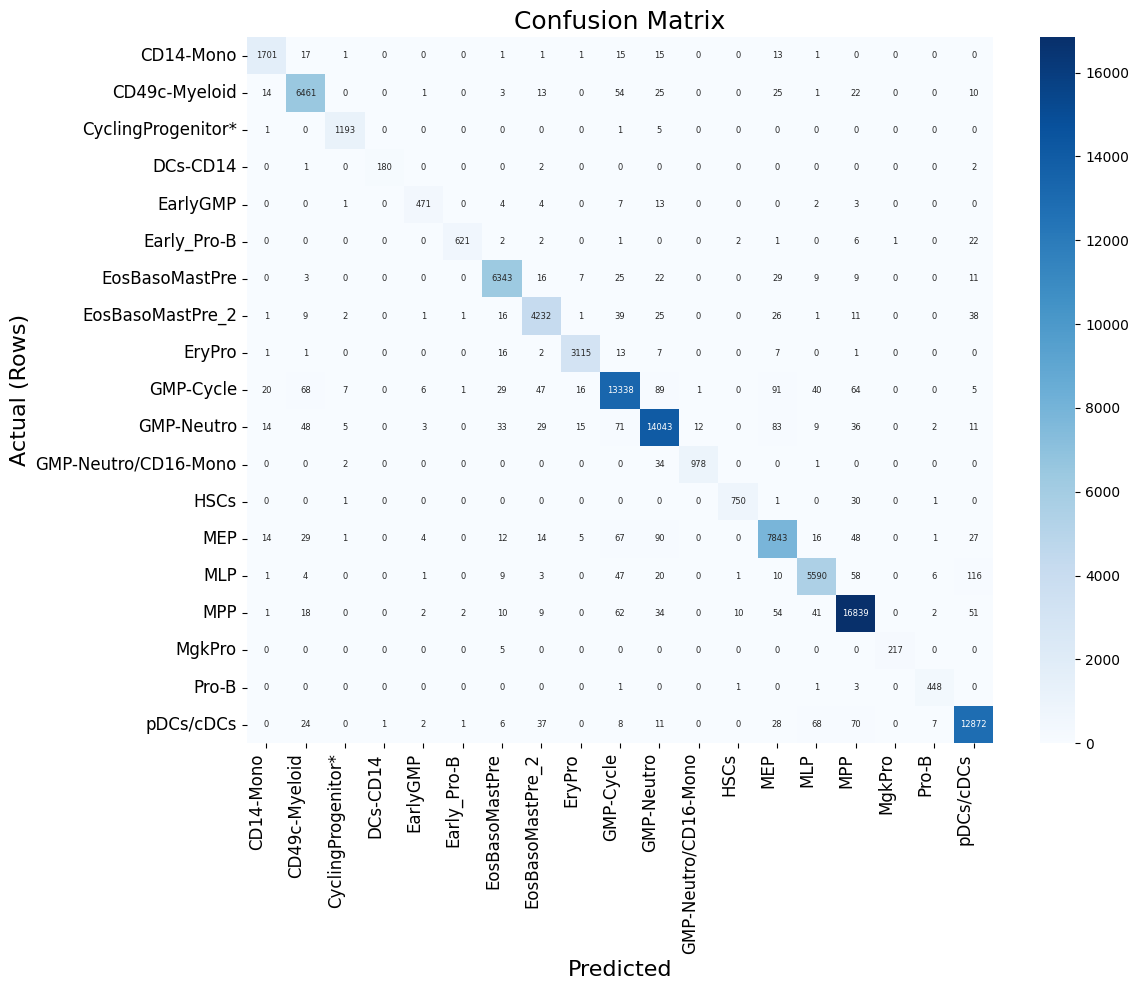

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(label_concat, ct_predictions_str)

# Get labels (adjust if you have a predefined order)
labels = sorted(set(label_concat))

plt.figure(figsize=(12, 10))  # bigger figure

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 6}  # bigger numbers
)

plt.xlabel("Predicted", fontsize=16)
plt.ylabel("Actual (Rows)", fontsize=16)
plt.title("Confusion Matrix", fontsize=18)

plt.xticks(rotation=90, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import classification_report

In [17]:
pd.DataFrame(classification_report(label_concat, ct_predictions_str, output_dict=True)).T

,precision,recall,f1-score,support
CD14-Mono,0.962104,0.963194,0.962649,1766.00000
CD49c-Myeloid,0.966781,0.974657,0.970703,6629.00000
CyclingProgenitor*,0.983512,0.994167,0.988811,1200.00000
DCs-CD14,0.994475,0.972973,0.983607,185.00000
EarlyGMP,0.959267,0.932673,0.945783,505.00000
Early_Pro-B,0.992013,0.943769,0.967290,658.00000
EosBasoMastPre,0.977500,0.979765,0.978631,6474.00000
EosBasoMastPre_2,0.959420,0.961163,0.960290,4403.00000
EryPro,0.985759,0.984825,0.985292,3163.00000
GMP-Cycle,0.970107,0.964983,0.967538,13822.00000
